# Read iGEM Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load files

In [15]:
projects_text = pd.read_csv(
    "/Users/cristian/Library/CloudStorage/GoogleDrive-cristianmejia00@gmail.com/My Drive/SynBio/igem_teams/team_project_descriptions_manual_entries_v2.tsv",
    sep="\t",
    encoding="iso-8859-1"
)

team_meta_full = pd.read_csv(
    "/Users/cristian/Library/CloudStorage/GoogleDrive-cristianmejia00@gmail.com/My Drive/SynBio/igem_teams/team_meta_full.tsv",
    sep="\t",
    encoding="utf-8"
)

In [16]:
team_meta_full['Status'].value_counts()

Status
accepted        4883
withdrawn        186
disqualified      27
Name: count, dtype: int64

## Work with accepted teams

In [17]:
team_meta_full = team_meta_full[team_meta_full['Status'] == 'accepted']

In [18]:
team_meta_full.columns


Index(['TeamID', 'Team', 'Region', 'Country', 'Kind', 'Section', 'Status',
       'Year', 'WikiURL', 'SoftwareURL', 'ApplicationDate', 'IsRemote',
       'Track', 'Topics', 'InstitutionCity', 'InstitutionName',
       'InstitutionState', 'InstitutionCountry', 'Competition', 'JudgingStart',
       'JudgingEnd'],
      dtype='object')

## Merge by team ID

In [19]:
df = team_meta_full.merge(projects_text, on='TeamID', how='left')

count_projectabstract = (
    df["ProjectAbstract"]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "nan": pd.NA, "NaN": pd.NA, "NAN": pd.NA})
    .notna()
    .sum()
)

print(count_projectabstract)

4707


## Get teams with descriptions

In [20]:
df = df[df['ProjectAbstract'].notna()]

## Column mapping

In [21]:
df.columns.tolist()

['TeamID',
 'Team_x',
 'Region',
 'Country',
 'Kind',
 'Section',
 'Status',
 'Year_x',
 'WikiURL',
 'SoftwareURL',
 'ApplicationDate',
 'IsRemote',
 'Track',
 'Topics',
 'InstitutionCity',
 'InstitutionName',
 'InstitutionState',
 'InstitutionCountry',
 'Competition',
 'JudgingStart',
 'JudgingEnd',
 'Year_y',
 'Team_y',
 'ProjectTitle',
 'ProjectAbstract']

In [22]:
dff = df.rename(columns={
    'TeamID': 'UT',
    'ProjectTitle': 'TI',
    'ProjectAbstract': 'AB',
    'Year_x': 'PY',
    'Team_x': 'AU',
    'Topics': 'WC',
    'WikiURL': 'DI',
    'Track': 'ID',
    'Country': 'Countries',
    'InstitutionName': 'Institutions',
})

dff['CR'] = ''
dff['C1'] = ''

## Summary statistics

In [23]:
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}\n')
print(f'Year range: {df["Year_x"].min()} – {df["Year_x"].max()}')
print(f'Unique countries: {df["Country"].nunique()}')
print(f'Unique institutions: {df["InstitutionName"].nunique()}')
print(f'Unique tracks: {df["Track"].nunique()}')
print(f'Unique topics: {df["Topics"].nunique()}')

Shape: (4707, 25)
Columns: ['TeamID', 'Team_x', 'Region', 'Country', 'Kind', 'Section', 'Status', 'Year_x', 'WikiURL', 'SoftwareURL', 'ApplicationDate', 'IsRemote', 'Track', 'Topics', 'InstitutionCity', 'InstitutionName', 'InstitutionState', 'InstitutionCountry', 'Competition', 'JudgingStart', 'JudgingEnd', 'Year_y', 'Team_y', 'ProjectTitle', 'ProjectAbstract']

Year range: 2004 – 2025
Unique countries: 68
Unique institutions: 3553
Unique tracks: 31
Unique topics: 16


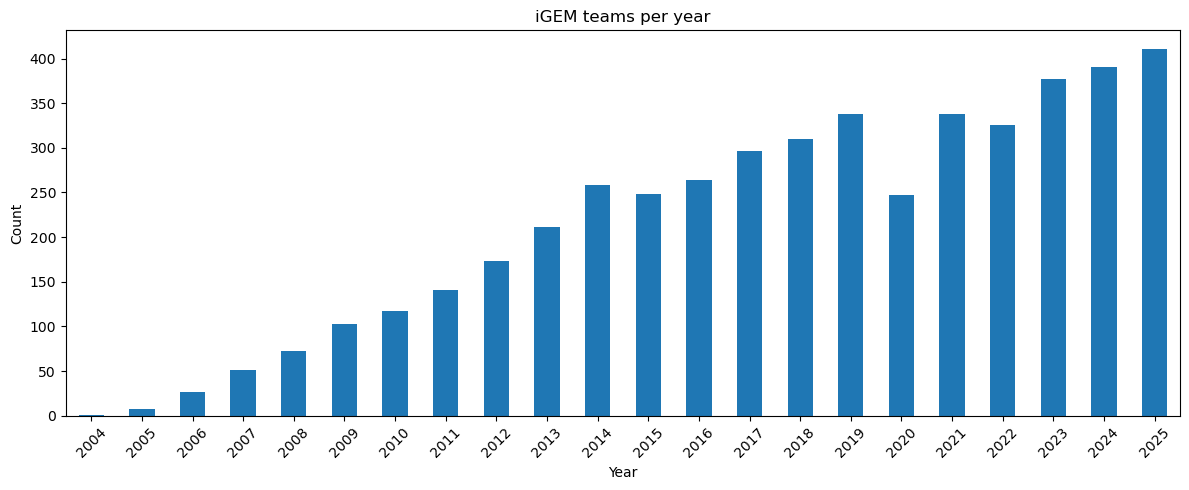

In [24]:
# Teams per year
yearly = df['Year_x'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind='bar', ax=ax)
ax.set_title('iGEM teams per year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

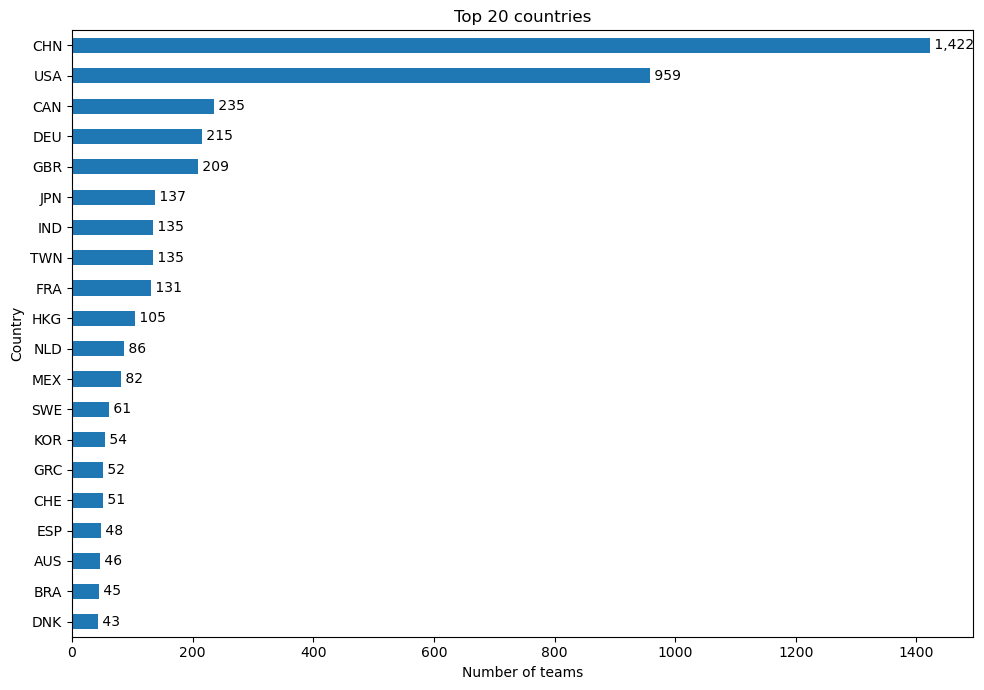

In [25]:
# Top 20 countries
top_countries = df['Country'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_countries.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('Top 20 countries')
for i, v in enumerate(top_countries):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

) missing from font(s) DejaVu Sans.tm9jr0000gn/T/ipykernel_75834/3029084321.py:11: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


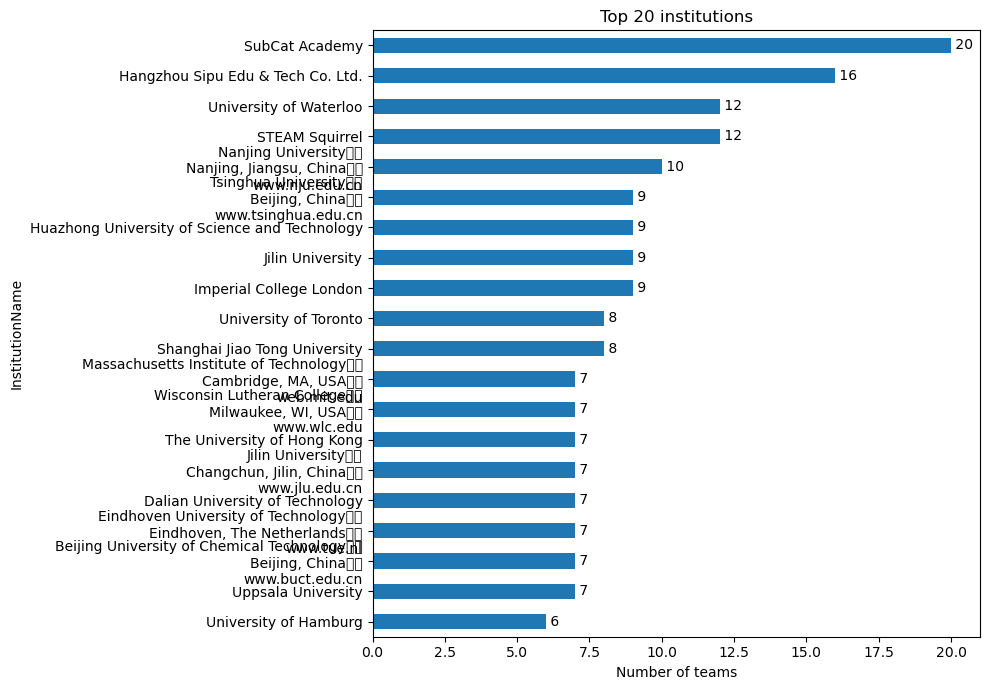

In [26]:
# Top 20 institutions
top_inst = df['InstitutionName'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_inst.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('Top 20 institutions')
for i, v in enumerate(top_inst):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

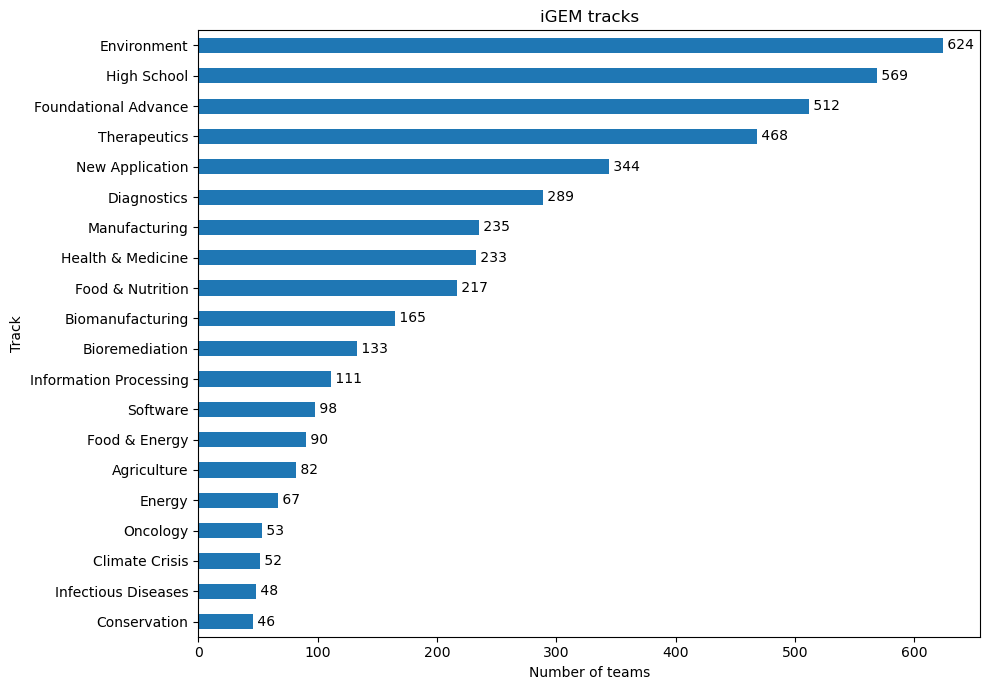

In [27]:
# Tracks
top_tracks = df['Track'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_tracks.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('iGEM tracks')
for i, v in enumerate(top_tracks):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

/var/folders/l3/ykgptl812qndpwdm6n3tm9jr0000gn/T/ipykernel_75834/1695386552.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


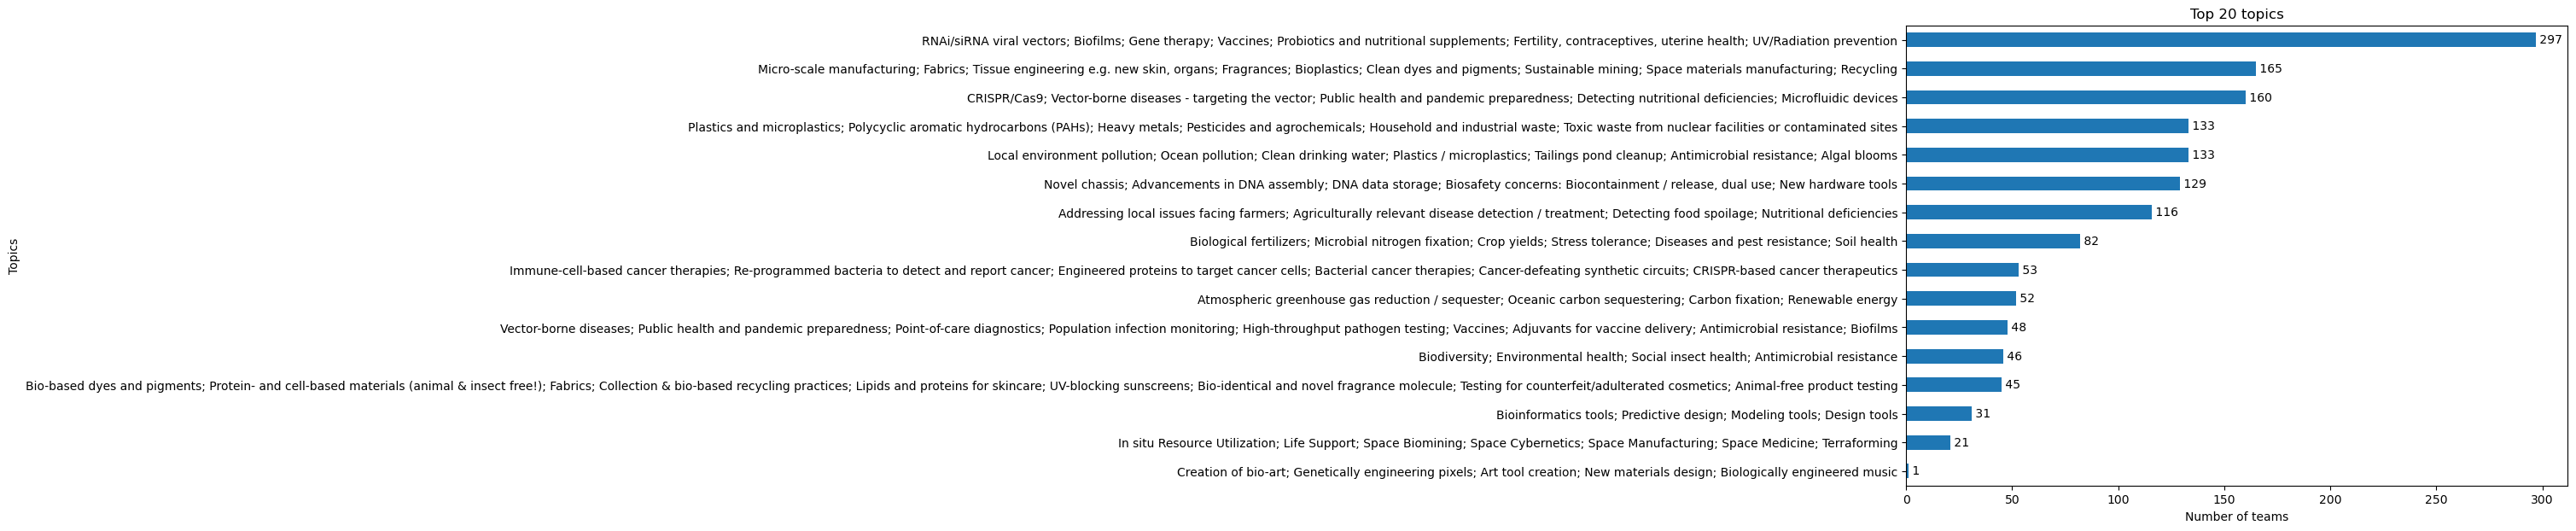

In [28]:
# Top 20 topics
top_topics = df['Topics'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_topics.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Number of teams')
ax.set_title('Top 20 topics')
for i, v in enumerate(top_topics):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()
plt.show()

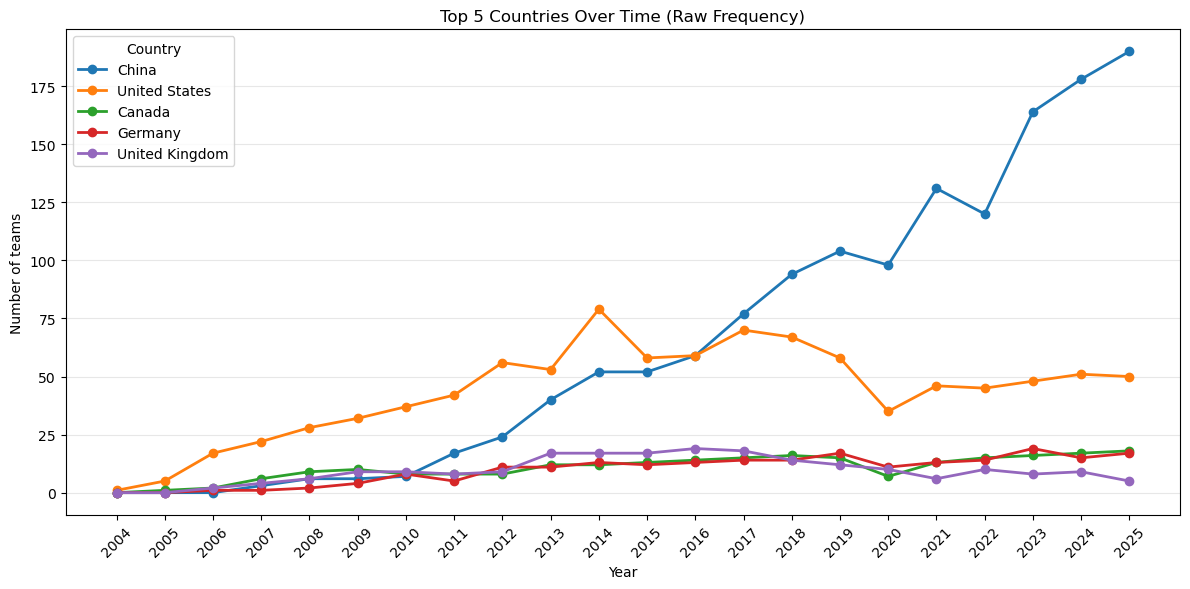

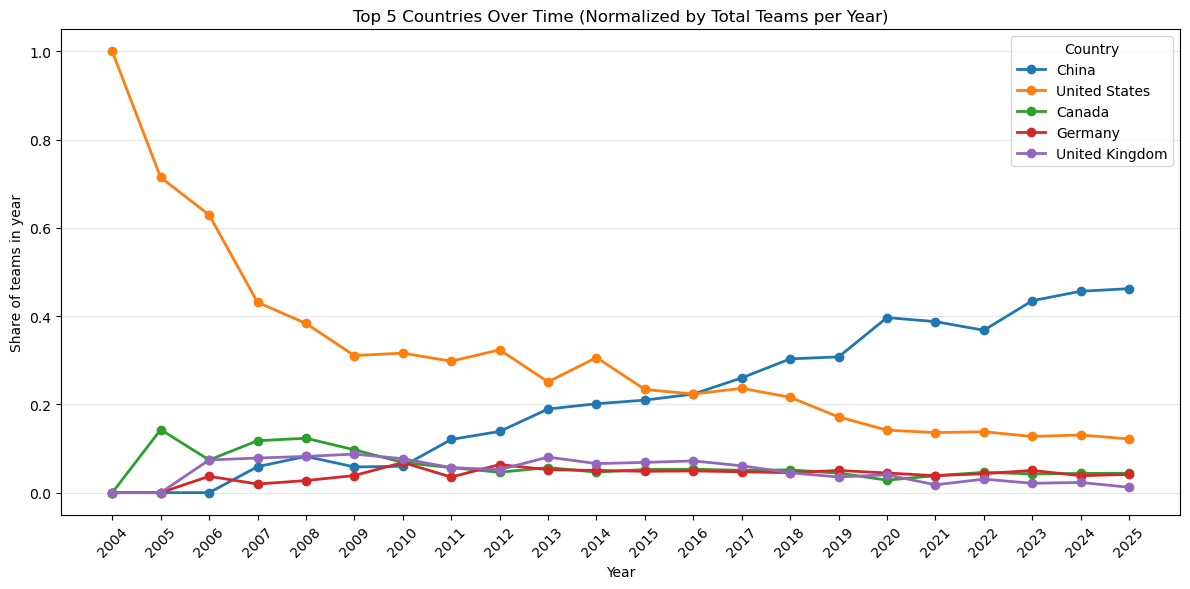

In [31]:
# Top 5 countries over time: raw and normalized frequencies
n_top = 5

plot_df = df[['Year_x', 'Country']].dropna().copy()
plot_df['Country'] = plot_df['Country'].astype(str).str.strip()
plot_df = plot_df[plot_df['Country'] != '']

# Keep years sorted and numeric when possible
plot_df['Year_x'] = pd.to_numeric(plot_df['Year_x'], errors='coerce')
plot_df = plot_df.dropna(subset=['Year_x'])
plot_df['Year_x'] = plot_df['Year_x'].astype(int)

years = sorted(plot_df['Year_x'].unique())

top_countries_overall = plot_df['Country'].value_counts().head(n_top).index.tolist()

country_year_counts = (
    plot_df[plot_df['Country'].isin(top_countries_overall)]
    .groupby(['Year_x', 'Country'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=years, columns=top_countries_overall, fill_value=0)
)

total_teams_per_year = (
    plot_df.groupby('Year_x')
    .size()
    .reindex(years, fill_value=0)
)

country_year_norm = country_year_counts.div(total_teams_per_year, axis=0).fillna(0)

# Convert common alpha-3 country codes to readable names for legends.
country_name_map = {
    'CHN': 'China',
    'USA': 'United States',
    'CAN': 'Canada',
    'DEU': 'Germany',
    'GBR': 'United Kingdom',
    'FRA': 'France',
    'ESP': 'Spain',
    'ITA': 'Italy',
    'NLD': 'Netherlands',
    'IND': 'India',
    'JPN': 'Japan',
    'KOR': 'South Korea',
    'MEX': 'Mexico',
    'BRA': 'Brazil',
    'AUS': 'Australia',
    'CHE': 'Switzerland',
    'SWE': 'Sweden',
    'DNK': 'Denmark',
    'BEL': 'Belgium',
    'AUT': 'Austria',
}


def country_display_name(code):
    code_str = str(code).strip()
    if code_str in country_name_map:
        return country_name_map[code_str]
    if len(code_str) == 3 and code_str.isupper():
        return code_str
    return code_str.title()


country_labels = {country: country_display_name(country) for country in top_countries_overall}

# Stable color mapping shared by both charts
cmap = plt.get_cmap('tab10')
country_colors = {country: cmap(i) for i, country in enumerate(top_countries_overall)}

# Figure 1: raw frequency
fig, ax = plt.subplots(figsize=(12, 6))
for country in top_countries_overall:
    ax.plot(
        country_year_counts.index,
        country_year_counts[country],
        marker='o',
        linewidth=2,
        label=country_labels[country],
        color=country_colors[country]
    )

ax.set_title('Top 5 Countries Over Time (Raw Frequency)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of teams')
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

# Figure 2: normalized frequency
fig, ax = plt.subplots(figsize=(12, 6))
for country in top_countries_overall:
    ax.plot(
        country_year_norm.index,
        country_year_norm[country],
        marker='o',
        linewidth=2,
        label=country_labels[country],
        color=country_colors[country]
    )

ax.set_title('Top 5 Countries Over Time (Normalized by Total Teams per Year)')
ax.set_xlabel('Year')
ax.set_ylabel('Share of teams in year')
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

## Save as input file

In [29]:
dff.to_csv('../assets/igem.txt', sep='\t', index=False)